# artificial-neuron

The paper that **created the first artificial neuron** — reproduced in modern Python and **plotted** so you can *see* each idea. It's a simple paper reproduction *and* a gentle primer in **computational modeling of neuroscience**: watch a biological neuron get turned into a few lines of math.

> Warren S. McCulloch & Walter Pitts (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity.* The Bulletin of Mathematical Biophysics 5(4):115–133. [doi:10.1007/BF02478259](https://doi.org/10.1007/BF02478259)

Run the cells top to bottom; each one adds a single piece.

## Where it came from: a real neuron

McCulloch & Pitts started with the **biological neuron**. A neuron collects signals from other neurons through its **dendrites**, the **soma** (cell body) adds those signals together, and if the total is strong enough to cross a threshold at the **axon hillock**, the neuron "fires" an **all-or-none** spike down its **axon** to the next neurons. Some incoming connections are **excitatory** (push it toward firing); others are **inhibitory** (hold it back).

![A biological neuron: dendrites receive signals, the soma sums them, and if the total crosses the axon hillock's threshold the axon fires an all-or-none spike; an inhibitory synapse can block it.](images/biological-neuron.png)

## Modeling it: the first artificial neuron

Their insight: because a neuron is **all-or-none** (it fires or it doesn't), you can capture what it *does* in pure logic. Strip the biology down to its essentials and you get an **artificial neuron** — the exact same shape, now as something you can compute:

![The artificial neuron: inputs are summed, and if the total reaches the threshold it returns 1 (fire) else 0 (silent); an inhibitory input forces 0.](images/artificial-neuron.png)

Part for part, the biology maps straight onto the code:

| Biological neuron | What it does | In the artificial neuron (code) |
|---|---|---|
| Dendrites & synapses | receive signals from other neurons | the `inputs` list (each `0` or `1`) |
| Excitatory vs. inhibitory synapse | nudge toward firing / block it | counted inputs vs. the `inhibited` veto |
| Soma | adds the incoming signals together | `sum(inputs)` |
| Axon hillock + threshold | fire only if the total is strong enough | `total >= threshold` |
| Action potential (all-or-none) | a full spike, or nothing at all | returns `1` or `0` |
| Axon | carries the output onward | the function's return value |

**Modeling means keeping what matters and idealizing the rest.** McCulloch & Pitts made a few deliberate simplifications: signals are **all-or-none** (no graded strengths), inputs are combined by **plain counting** with **no tunable, real-valued weights** (those arrive 15 years later, with the perceptron), **inhibition is absolute** (one inhibitor always wins), and **time runs in discrete ticks**. Those choices are exactly what turn a messy biological cell into a clean piece of **logic** — and that act of rewriting a biological mechanism as something computable is the heart of computational neuroscience.

> Because it applies a **threshold** to a **linear** sum of its inputs, this artificial neuron is also called a **threshold logic unit (TLU)** or a **linear threshold unit (LTU)**. *McCulloch–Pitts neuron, artificial neuron, TLU, LTU* — four names for the same object. The rest of this notebook builds it.

### Words to know

- **all-or-none** — a neuron is either fully *firing* (`1`) or *silent* (`0`); nothing in between.
- **threshold** — how large the input total must be to make the neuron fire.
- **excitatory input** — an input that pushes the neuron *toward* firing (it gets counted).
- **inhibitory input** — an input that *vetoes* firing (one active inhibitor is enough to silence it).
- **linearly separable** — a problem you can solve by drawing one straight line between the “yes” and “no” cases. A single artificial neuron can only do these.

## 1. The neuron: count, then threshold

Here is the whole biological story above, in three lines: **add up the inputs, and fire if the total reaches a threshold.** No weights, no learning — just counting and a cutoff.

In [1]:
def neuron(inputs, threshold):
    total = sum(inputs)                     # the SOMA: add up the inputs that are ON
    return 1 if total >= threshold else 0   # the THRESHOLD: fire (1) only if the total is big enough

In [2]:
print("both inputs on:", neuron([1, 1], threshold=2))
print("one input on:  ", neuron([1, 0], threshold=2))

both inputs on: 1
one input on:   0


## 2. The threshold alone picks the gate

Here's the first surprise: **the threshold by itself turns this one neuron into different logic gates.**

- Threshold **2** → fires only when *both* inputs are on → **AND**.
- Threshold **1** → *either* input is enough → **OR**.

In [3]:
def AND(a, b):
    return neuron([a, b], threshold=2)   # fires only if BOTH are on (total reaches 2)

def OR(a, b):
    return neuron([a, b], threshold=1)   # fires if EITHER is on (total reaches 1)

bits = [(0, 0), (0, 1), (1, 0), (1, 1)]
for name, gate in [("AND", AND), ("OR", OR)]:
    print(name)
    for a, b in bits:
        print(f"  {a} {b} -> {gate(a, b)}")

AND
  0 0 -> 0
  0 1 -> 0
  1 0 -> 0
  1 1 -> 1
OR
  0 0 -> 0
  0 1 -> 1
  1 0 -> 1
  1 1 -> 1


Let's *see* it — the neuron's output as the number of active inputs grows. The jump from 0 to 1 is the **all-or-none threshold**, and AND simply jumps one step later than OR. (The curves are computed by calling the real `AND` / `OR` neurons.)

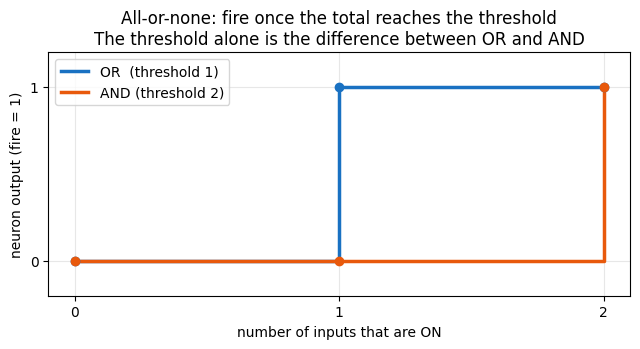

In [4]:
import matplotlib.pyplot as plt

# build the curves by calling the ACTUAL OR / AND neurons (no recreated logic)
inputs_with = {0: (0, 0), 1: (1, 0), 2: (1, 1)}      # how many inputs are ON -> an input pair
totals  = [0, 1, 2]
or_out  = [OR(*inputs_with[t])  for t in totals]     # the real OR  neuron at each point
and_out = [AND(*inputs_with[t]) for t in totals]     # the real AND neuron at each point

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.step(totals, or_out,  where="post", lw=2.5, color="#1971c2", label="OR  (threshold 1)")
ax.step(totals, and_out, where="post", lw=2.5, color="#e8590c", label="AND (threshold 2)")
ax.scatter(totals, or_out,  color="#1971c2", zorder=3)
ax.scatter(totals, and_out, color="#e8590c", zorder=3)
ax.set_xticks(totals); ax.set_yticks([0, 1]); ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("number of inputs that are ON"); ax.set_ylabel("neuron output (fire = 1)")
ax.set_title("All-or-none: fire once the total reaches the threshold\nThe threshold alone is the difference between OR and AND")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. We hit a wall: NOT

Now try to build **NOT** — "fire when the input is *off*." You can't: adding inputs only ever pushes a neuron *toward* firing, never away from it.

This is where the biological **inhibitory synapse** earns its place in the model. In 1943 it's *absolute*: **a single inhibitory signal vetoes firing entirely**, no matter the total.

In [5]:
def neuron(inputs, threshold, inhibited=False):
    if inhibited:                           # an INHIBITORY input vetoes everything
        return 0
    total = sum(inputs)
    return 1 if total >= threshold else 0

Now **NOT** is a neuron that's *on by default* (threshold `0`, no excitatory inputs) which its input simply switches off.

In [6]:
def NOT(a):
    return neuron([], threshold=0, inhibited=bool(a))   # on by default; 'a' switches it off

print("NOT")
for a in (0, 1):
    print(f"  {a} -> {NOT(a)}")

NOT
  0 -> 1
  1 -> 0


## 4. Wire neurons into a network → *any* logic (XOR)

A single artificial neuron draws exactly **one straight line** through its inputs — so it can only solve **linearly separable** problems. **XOR** ("one or the other, but not both") isn't one. Each panel plots the four inputs, marked by output (filled = fires, hollow = silent); the question is whether one line can fence the `1`s off from the `0`s.

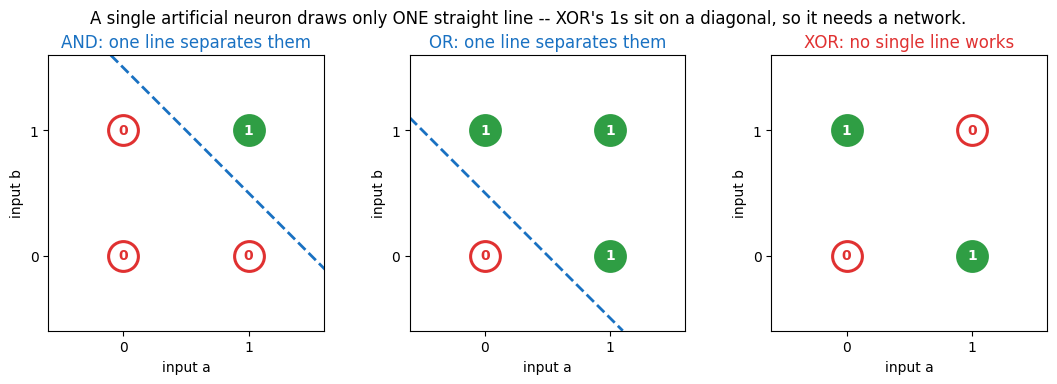

In [7]:
import matplotlib.pyplot as plt

def XOR(a, b):
    return AND(OR(a, b), NOT(AND(a, b)))   # a network of three neurons we already built

# the neuron's OWN decision boundary: it fires when a+b >= threshold, so the
# separating line is a+b = threshold-0.5 (derived from each gate's threshold).
gate_threshold = {"AND": 2, "OR": 1}
def boundary_line(theta):
    c = theta - 0.5
    return [c - 1.6, c + 0.6], [1.6, -0.6]            # two endpoints on the line a+b = c

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7))
for ax, (name, gate) in zip(axes, [("AND", AND), ("OR", OR), ("XOR", XOR)]):
    for a in (0, 1):
        for b in (0, 1):
            out = gate(a, b)                              # the ACTUAL neuron's output
            ax.scatter(a, b, s=460, zorder=3,
                       c=("#2f9e44" if out else "white"),
                       edgecolors=("#2f9e44" if out else "#e03131"), linewidths=2.2)
            ax.text(a, b, str(out), ha="center", va="center", zorder=4,
                    color=("white" if out else "#e03131"), fontweight="bold")
    if name in gate_threshold:
        ax.plot(*boundary_line(gate_threshold[name]), "--", color="#1971c2", lw=2)
        ax.set_title(f"{name}: one line separates them", color="#1971c2")
    else:
        ax.set_title("XOR: no single line works", color="#e03131")
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(-0.6, 1.6); ax.set_aspect("equal")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("input a"); ax.set_ylabel("input b")

fig.suptitle("A single artificial neuron draws only ONE straight line -- XOR's 1s sit on a diagonal, so it needs a network.")
plt.tight_layout(); plt.show()

That diagonal is exactly what **"not linearly separable"** means. The fix is McCulloch & Pitts' real result: **a *network* of these neurons can compute anything.**

```
   a ─┬───────────────► OR(a,b) ───────────────┐
      │                                          ├─► AND ─► XOR
   b ─┴─► AND(a,b) ─► NOT(AND(a,b)) ─────────────┘

   XOR = AND( OR(a, b) , NOT(AND(a, b)) )
```

> **A note on history.** The "*a single neuron can't do XOR — it isn't linearly separable*" way of seeing the limit came **later** (Minsky & Papert, 1969). What McCulloch & Pitts themselves proved in 1943 is the half that fixes it — that a *network* of these neurons can realize **any** logical expression (their Theorems I & II). We borrow the linear-separability picture only because it makes *why* you need a network easy to see.

In [8]:
print("XOR")
for a, b in bits:
    print(f"  {a} {b} -> {XOR(a, b)}")

XOR
  0 0 -> 0
  0 1 -> 1
  1 0 -> 1
  1 1 -> 0


## 5. Loop it → memory

Everything so far flows forward. Now **feed a neuron's own output back into itself** — that loop is what lets it *remember*. Once a `set` input switches it on, it keeps re-firing (it **reverberates**) until a `reset` inhibits it. The authors call this firing “a memory — or an idea.”

In [9]:
def memory_step(set_now, reset_now, was_on):
    # the neuron sees the SET signal AND its own previous output (was_on).
    # that feedback -- its output looping back in -- is what lets it remember.
    return neuron([set_now, was_on], threshold=1, inhibited=bool(reset_now))

In [10]:
# (set, reset) at each tick of time:  set at t=1, reset at t=4
ticks = [(0, 0), (1, 0), (0, 0), (0, 0), (0, 1), (0, 0)]

states, state = [], 0
print("t   set reset   state")
for t, (set_now, reset_now) in enumerate(ticks):
    state = memory_step(set_now, reset_now, state)
    states.append(state)
    print(f"{t}    {set_now}    {reset_now}       {state}")

t   set reset   state
0    0    0       0
1    1    0       1
2    0    0       1
3    0    0       1
4    0    1       0
5    0    0       0


Plotted over time (straight from the neuron's own outputs), you can watch the state turn on at **set**, **hold by itself** with no further input, then clear at **reset**:

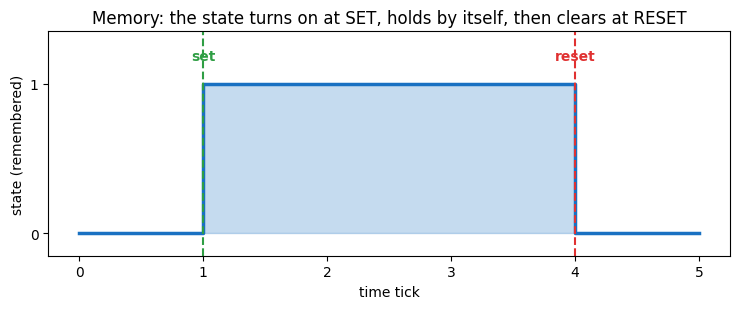

In [11]:
import matplotlib.pyplot as plt

T = list(range(len(ticks)))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.fill_between(T, states, step="post", alpha=0.25, color="#1971c2")
ax.step(T, states, where="post", lw=2.5, color="#1971c2")
for t, (set_now, reset_now) in zip(T, ticks):
    if set_now:
        ax.axvline(t, color="#2f9e44", ls="--"); ax.text(t, 1.16, "set", color="#2f9e44", ha="center", fontweight="bold")
    if reset_now:
        ax.axvline(t, color="#e03131", ls="--"); ax.text(t, 1.16, "reset", color="#e03131", ha="center", fontweight="bold")
ax.set_ylim(-0.15, 1.35); ax.set_yticks([0, 1]); ax.set_xticks(T)
ax.set_xlabel("time tick"); ax.set_ylabel("state (remembered)")
ax.set_title("Memory: the state turns on at SET, holds by itself, then clears at RESET")
plt.tight_layout(); plt.show()

## Self-check

A few assertions so the notebook proves itself — if any result disagreed with the paper, the cell would error.

In [12]:
assert [AND(a, b) for a, b in bits] == [0, 0, 0, 1]
assert [OR(a, b) for a, b in bits]  == [0, 1, 1, 1]
assert [NOT(a) for a in (0, 1)]     == [1, 0]
assert [XOR(a, b) for a, b in bits] == [0, 1, 1, 0]
assert states == [0, 1, 1, 1, 0, 0]
print("All checks pass -- one neuron, four ideas, true to 1943.")

All checks pass -- one neuron, four ideas, true to 1943.


## The whole artificial neuron, in one place

We grew it across the notebook; here it is complete. That's the entire McCulloch–Pitts artificial neuron (a.k.a. threshold logic unit):

```python
def neuron(inputs, threshold, inhibited=False):
    if inhibited:                           # absolute inhibition: one veto stops it
        return 0
    total = sum(inputs)                     # the soma: count the active excitatory inputs
    return 1 if total >= threshold else 0   # the threshold: fire if the count is big enough
```

## Why it matters

A handful of lines, copied from a brain cell — and a network of them is exactly a **finite-state machine** (logic + memory). McCulloch & Pitts close with the famous result: a net *"furnished with a tape… can compute only such numbers as can a Turing machine."* So **network + an external memory tape = a universal computer**. By modeling one biological neuron as pure logic, they built the bridge from *brains* to *computers* — and the artificial neuron every neural network since is made of.

---

*Educational reproduction by [Average Joes Lab](https://averagejoeslab.com). All credit for the ideas to McCulloch & Pitts (1943).*